In [1]:
import os

os.makedirs("../csv", exist_ok=True)
os.makedirs("../svg", exist_ok=True)

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots

In [3]:
plt.rcParams.update({
    'font.family': 'TeX Gyre Termes',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

In [4]:
TEXTWIDTH_PT = 426.79137
TEXTHEIGHT_PT = 702.78308
PT_PER_INCH = 72.27

FIG_WIDTH = TEXTWIDTH_PT / PT_PER_INCH
FIG_HEIGHT_1 = TEXTHEIGHT_PT / PT_PER_INCH
FIG_HEIGHT_2 = FIG_HEIGHT_1 / 2
FIG_HEIGHT_3 = FIG_HEIGHT_1 / 3
FIG_HEIGHT_4 = FIG_HEIGHT_1 / 4
FIG_HEIGHT_5 = FIG_HEIGHT_1 / 5
FIG_HEIGHT_6 = FIG_HEIGHT_1 / 6
FIG_HEIGHT_7 = FIG_HEIGHT_1 / 7
FIG_HEIGHT_8 = FIG_HEIGHT_1 / 8

In [5]:
def parse_turbostat(filepath):
    samples = []
    current = {}

    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if not parts:
                continue

            if parts[0] == "CPU":
                if current:
                    samples.append(current)
                continue

            cpu = "system" if parts[0] == "-" else f"cpu{parts[0]}"
            if cpu != "system":
                current[f"{cpu}"] = int(parts[2])
            if len(parts) > 3 and cpu == "system":
                current[f"{cpu}_pkg_watt"] = float(parts[3])

        if current:
            samples.append(current)

    df = pd.DataFrame(samples)
    cpu_cols_local = sorted(
        [c for c in df.columns if c.startswith("cpu")],
        key=lambda x: int(x.replace("cpu", ""))
    )
    df["system"] = df[cpu_cols_local].mean(axis=1)
    return df

In [6]:
def parse_pm(filepath):
    samples = []
    current = {}

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith("*** Sampled system activity"):
                if current and any(k.startswith("cpu") for k in current):
                    samples.append(current)
                current = {}
                continue
            if line.startswith("CPU ") and "frequency:" in line:
                parts = line.split()
                current[f"cpu{int(parts[1])}"] = int(parts[3])
                continue
            if line.startswith("CPU Power:"):
                current["system_pkg_watt"] = float(line.split()[2]) / 1000.0

    if current and any(k.startswith("cpu") for k in current):
        samples.append(current)

    df = pd.DataFrame(samples)
    cpu_cols_local = sorted(
        [c for c in df.columns if c.startswith("cpu")],
        key=lambda x: int(x.replace("cpu", ""))
    )
    df["system"] = df[cpu_cols_local].mean(axis=1)
    return df


In [7]:
def prec(df, cols, n, q):
    t = stats.t.ppf(q, df=n-1)

    cv_df = df[cols].copy()
    cv_df = cv_df.replace(0, np.nan)

    x = cv_df.stack().mean()
    s = cv_df.stack().std()

    cv = (s / x) * 100
    d = t * cv / np.sqrt(n)

    return d

In [8]:
def plot_turbostat(df_raw, cpu_cols, power_scale, width, filename):
    df_raw = df_raw.iloc[8:].reset_index(drop=True).copy()
    df_freq = df_raw[cpu_cols].replace(0, np.nan)
    df_freq["sample"] = np.arange(len(df_freq))
    df_freq_long = df_freq.melt(
        id_vars="sample", var_name="CPU", value_name="freq"
    )

    df_watt = pd.DataFrame({
        "sample": np.arange(len(df_raw)),
        "watt": df_raw["system_pkg_watt"].values,
    })

    freq_min = df_freq[cpu_cols].min().min()
    freq_max = df_freq[cpu_cols].max().max()

    watt_max = df_watt["watt"].max()

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(width, FIG_HEIGHT_3), layout='constrained', sharex=True,
            gridspec_kw={"height_ratios": [2, 1]},
        )

        sns.lineplot(
            data=df_freq_long, x="sample", y="freq", hue="CPU",
            palette=["#4C9BE8"] * len(cpu_cols),
            linewidth=0.7, alpha=0.25, legend=False, ax=ax1,
        )

        median_freq = df_raw[cpu_cols].median(axis=1)
        sns.lineplot(
            x=np.arange(len(median_freq)), y=median_freq.values,
            color="#1F4E79", linewidth=1.6,
            label="Mediana rdzeni", ax=ax1,
        )

        ax1.set_ylim(np.floor(freq_min / 100) * 100, np.ceil(freq_max / 100) * 100)
        ax1.set_ylabel("Częstotliwość [MHz]")
        ax1.set_xlabel("")
        ax1.legend(loc="lower right", frameon=False)

        sns.lineplot(
            data=df_watt, x="sample", y="watt",
            color="#C0392B", linewidth=1.0, ax=ax2,
        )
        ax2.fill_between(
            df_watt["sample"], 0, df_watt["watt"],
            color="#C0392B", alpha=0.12,
        )

        ax2.set_ylim(0, np.ceil(watt_max / power_scale) * power_scale)
        ax2.set_ylabel("Pobór mocy [W]")
        ax2.set_xlabel("Numer próbki")

        plt.savefig(f'../svg/{filename}.svg', facecolor='white')
        plt.show()

In [9]:
def plot_compare(df_compare, order, filename):
    freq_min = df_compare["freq_mhz"].min() - 100
    freq_max = df_compare["freq_mhz"].max() + 100

    watt_min = df_compare["pkg_watt"].min()
    watt_max = df_compare["pkg_watt"].max()

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH / 2, FIG_HEIGHT_4), layout='constrained')
        sns.boxplot(
            data=df_compare, x="backend", y="freq_mhz",
            order=order, hue="backend",
            legend=False, ax=ax,
            width=0.6
        )

        ax.set_ylim(np.floor(freq_min / 250) * 250, np.ceil(freq_max / 250) * 250)
        ax.set_xlabel("Backend")
        ax.set_ylabel("Częstotliwość Bzy [MHz]")
        plt.savefig(f'../svg/{filename}_freq_compare.svg', facecolor='white')
        plt.show()

        fig, ax = plt.subplots(figsize=(FIG_WIDTH / 2, FIG_HEIGHT_4), layout='constrained')
        sns.boxplot(
            data=df_compare, x="backend", y="pkg_watt",
            order=order, hue="backend",
            legend=False, ax=ax,
            width=0.6
        )

        ax.set_ylim(max(np.floor((watt_min - 10) / 5), 0) * 5, np.ceil((watt_max + 10) / 5) * 5)
        ax.set_xlabel("Backend")
        ax.set_ylabel("Pobór mocy pakietu [W]")
        plt.savefig(f'../svg/{filename}_power_compare.svg', facecolor='white')
        plt.show()

In [10]:
def compare_backends(df, value_col, *, label, unit, prec=0, backend_col="backend", order=None):
    means = df.groupby(backend_col)[value_col].mean()
    if order is not None:
        means = means.reindex(order)

    grand = means.mean()
    vmin, vmax = means.min(), means.max()
    dev_pct = max(abs(vmin - grand), abs(vmax - grand)) / grand * 100

    print(f"{label} per backend:")
    for backend, val in means.items():
        diff_pct = (val - grand) / grand * 100
        print(f"  {backend:<8} {val:.{prec}f} {unit}  ({diff_pct:+.2f}% od średniej)")

    print(f"Zakres: {vmin:.{prec}f}–{vmax:.{prec}f} {unit} "
          f"(rozrzut {vmax - vmin:.{prec}f} {unit})")
    print(f"Średnia ze średnich: {grand:.{prec}f} {unit}, "
          f"maks. odchył od średniej: {dev_pct:.2f}%")

In [11]:
bench_turbostat = parse_turbostat("../data/turbostat-bench.txt")
system_turbostat = parse_turbostat("../data/turbostat-system.txt")
scalar_turbostat = parse_turbostat("../data/turbostat-search-Scalar.txt")
sse2_turbostat = parse_turbostat("../data/turbostat-search-Sse2.txt")
avx2_turbostat = parse_turbostat("../data/turbostat-search-Avx2.txt")
avx512_turbostat = parse_turbostat("../data/turbostat-search-Avx512.txt")
bench_pm = parse_pm("../data/pm-bench.txt")
system_pm = parse_pm("../data/pm-system.txt")
scalar_pm = parse_pm("../data/pm-search-Scalar.txt")
neon_pm = parse_pm("../data/pm-search-Neon.txt")

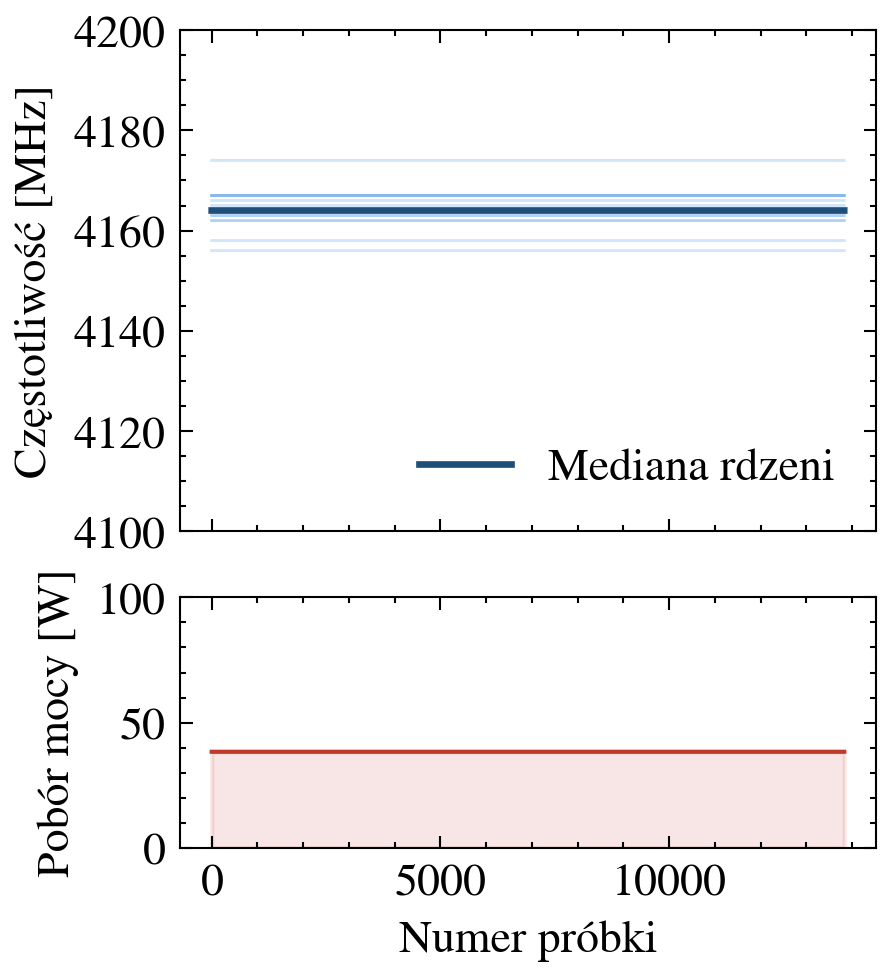

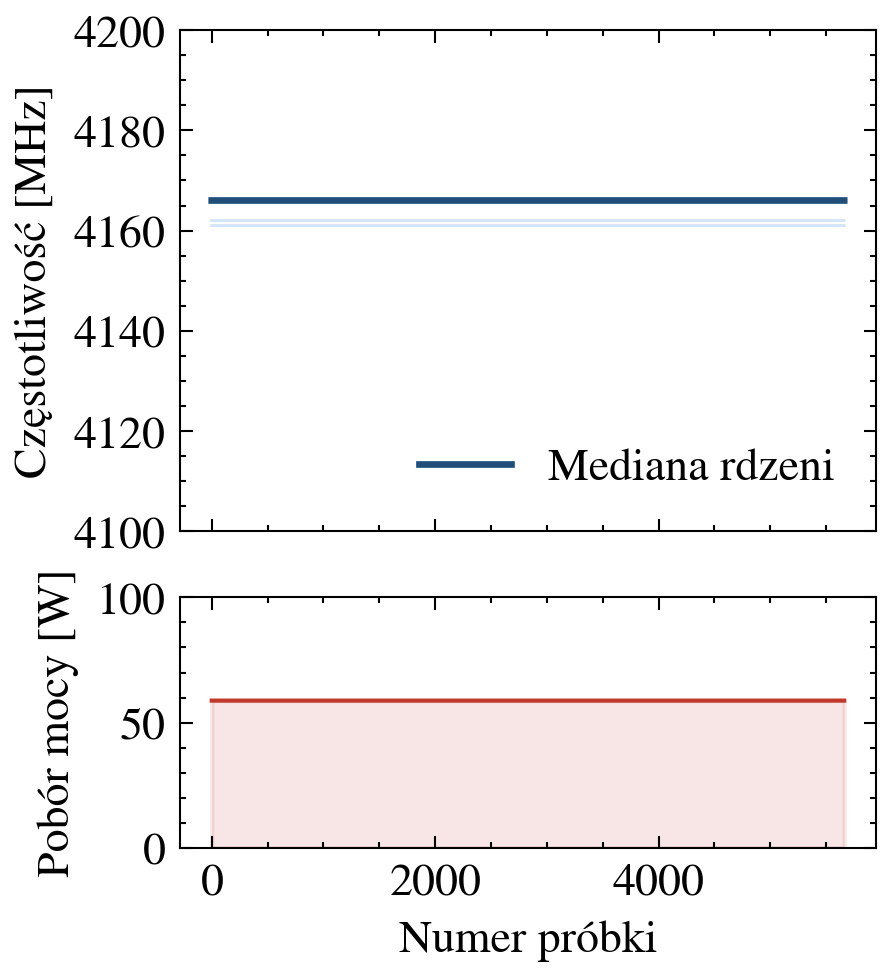

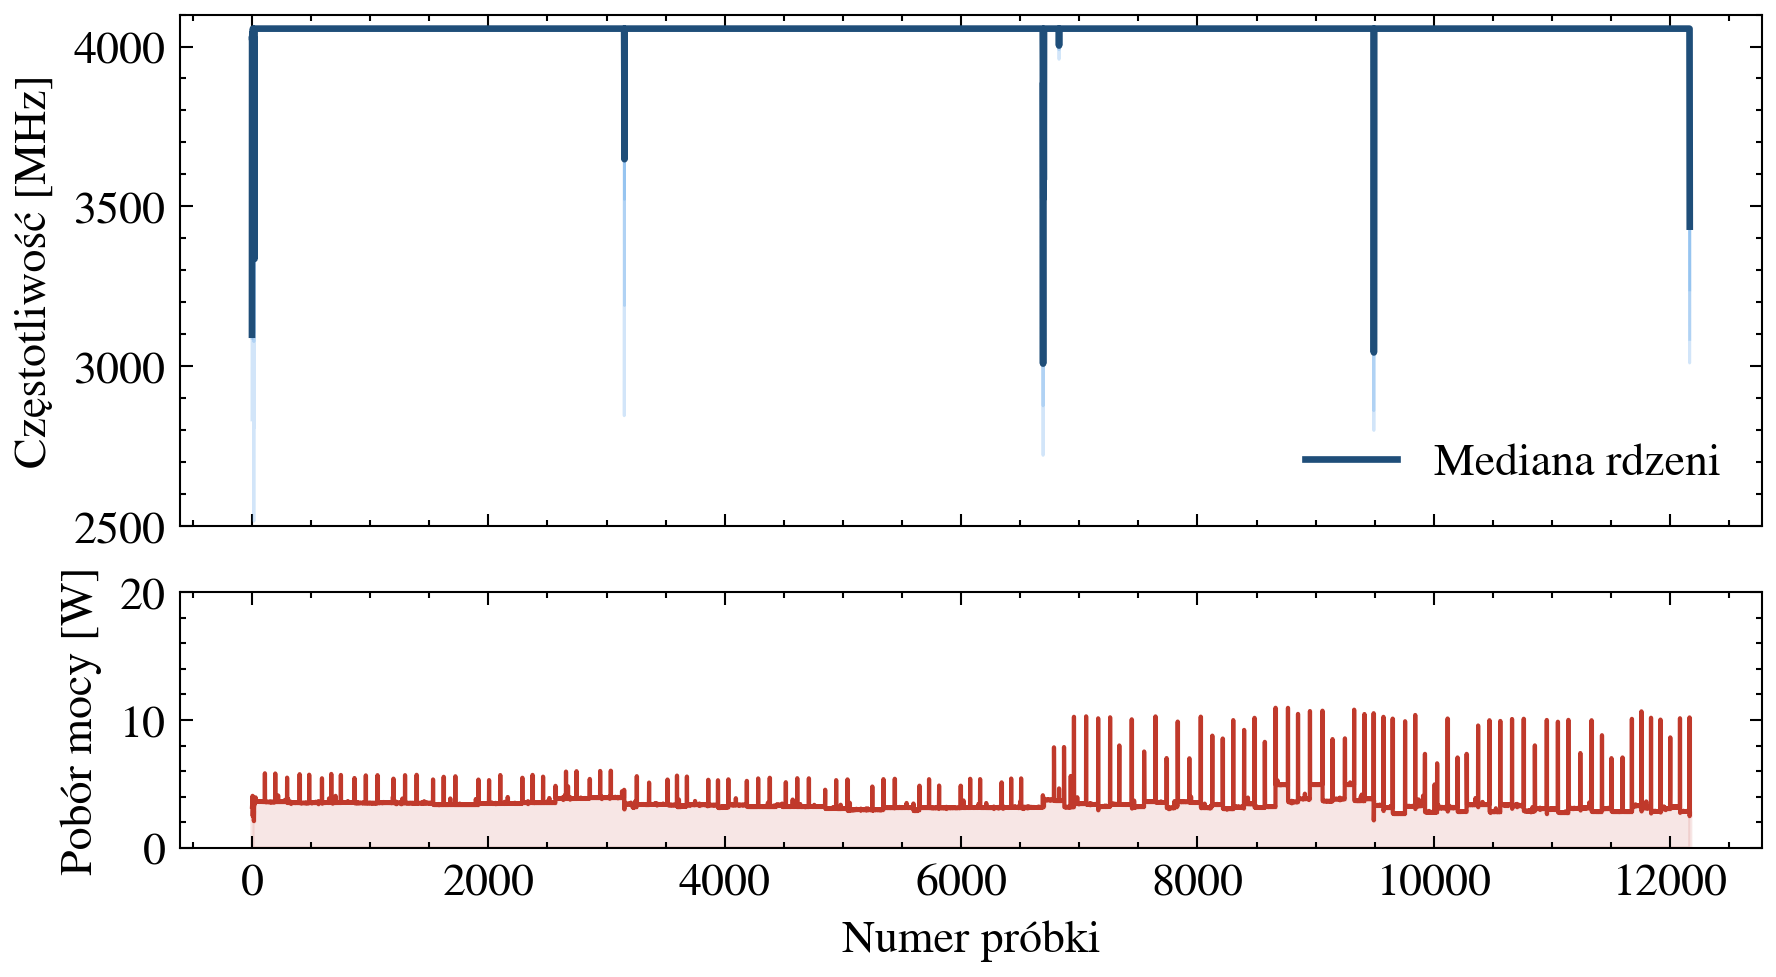

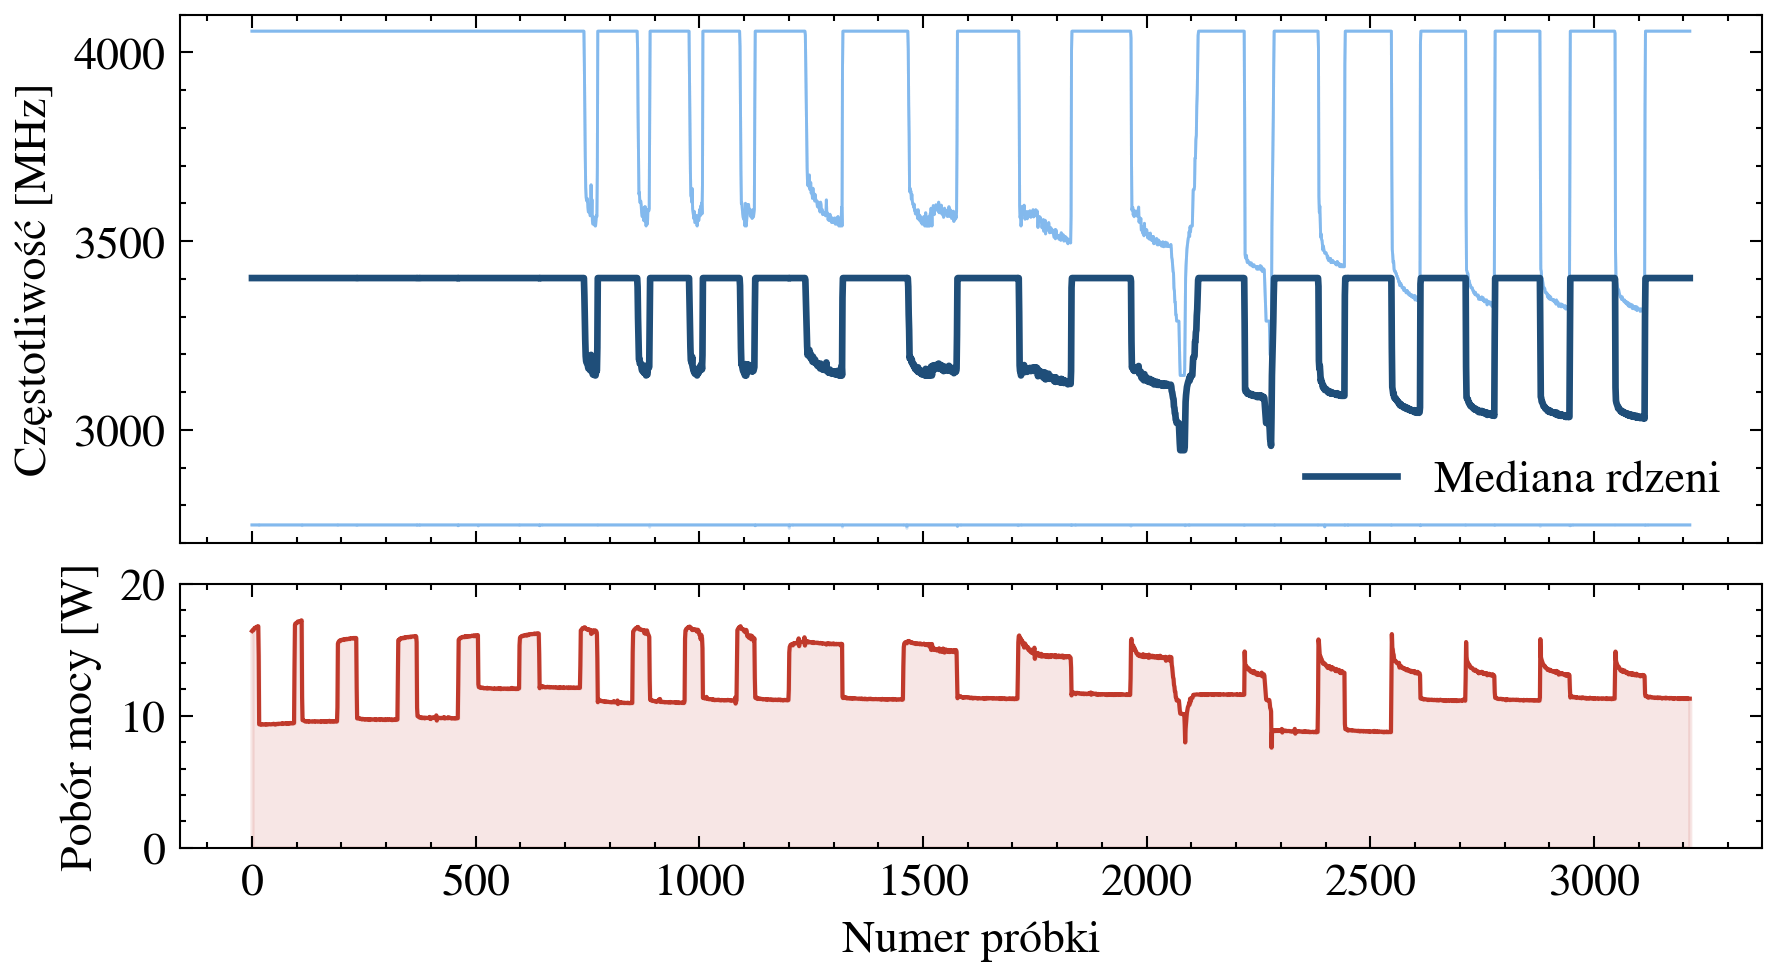

In [12]:
plot_turbostat(bench_turbostat, [f'cpu{i}' for i in range(0, 16)], 100, FIG_WIDTH / 2, "turbostat_bench")
plot_turbostat(system_turbostat, [f'cpu{i}' for i in range(0, 16)], 100, FIG_WIDTH / 2, "turbostat_system")
plot_turbostat(bench_pm, [f'cpu{i}' for i in range(4, 8)], 10, FIG_WIDTH, "pm_bench")
plot_turbostat(system_pm, [f'cpu{i}' for i in range(0, 8)], 10, FIG_WIDTH, "pm_system")

In [13]:
turbostat_backends = {
    "Scalar": scalar_turbostat,
    "SSE2": sse2_turbostat,
    "AVX2": avx2_turbostat,
    "AVX512": avx512_turbostat,
}

turbostat_compare = pd.concat(
    [
        df[["system", "system_pkg_watt"]]
        .rename(columns={"system": "freq_mhz", "system_pkg_watt": "pkg_watt"})
        .assign(backend=name)
        for name, df in turbostat_backends.items()
    ],
    ignore_index=True,
)

turbostat_backend_order = ["Scalar", "SSE2", "AVX2", "AVX512"]

pm_backends = {
    "Scalar": scalar_pm,
    "NEON": neon_pm,
}

pm_compare = pd.concat(
    [
        df[["system", "system_pkg_watt"]]
        .rename(columns={"system": "freq_mhz", "system_pkg_watt": "pkg_watt"})
        .assign(backend=name)
        for name, df in pm_backends.items()
    ],
    ignore_index=True,
)

pm_backend_order = ["Scalar", "NEON"]

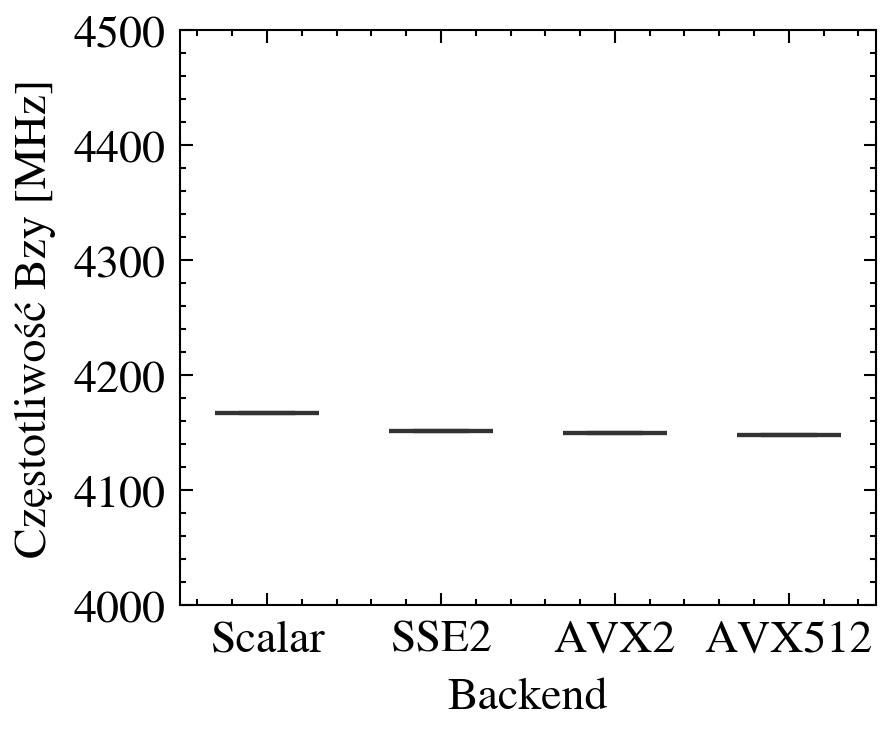

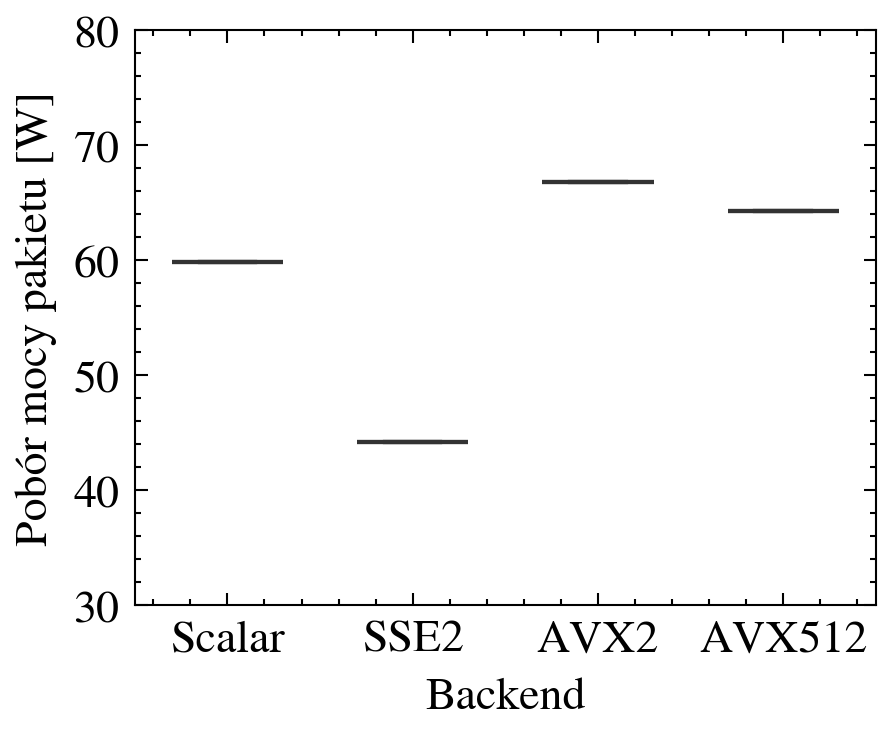

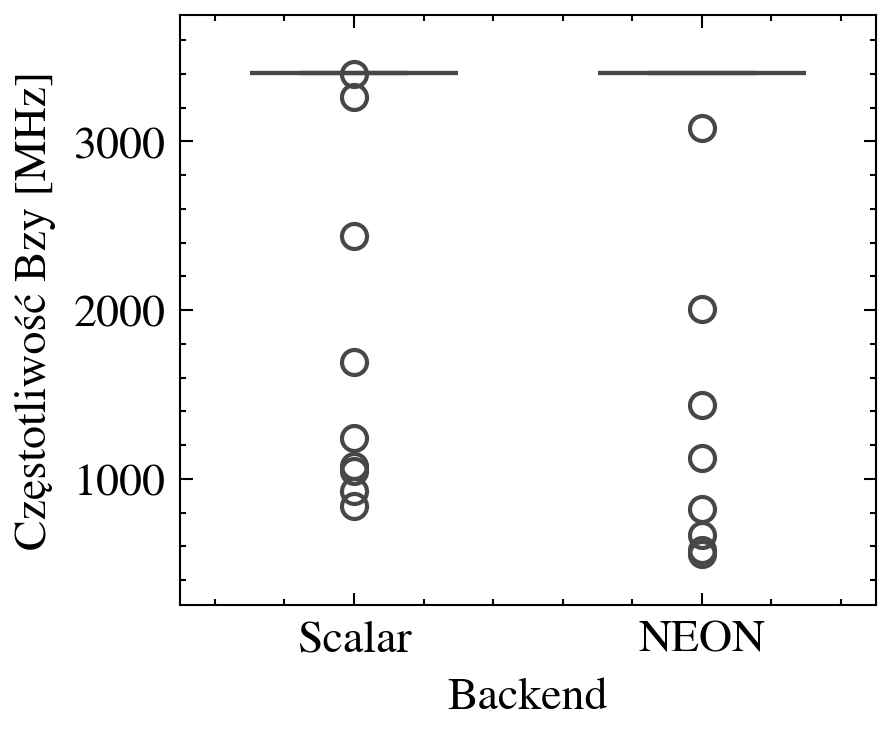

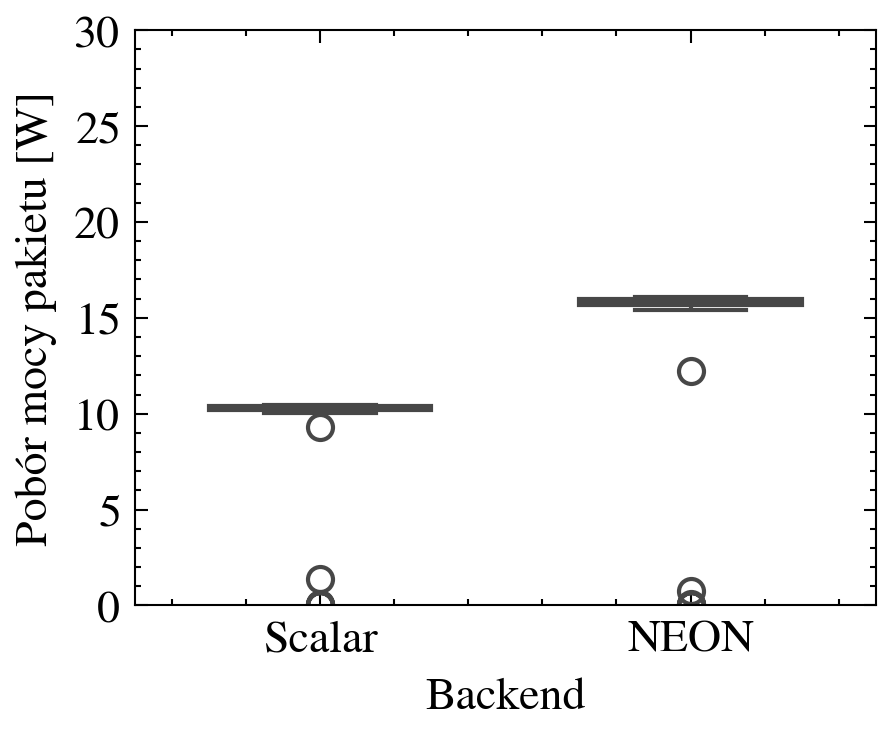

In [14]:
plot_compare(turbostat_compare, turbostat_backend_order, 'turbostat')
plot_compare(pm_compare, pm_backend_order, 'pm')

In [15]:
f = turbostat_compare["freq_mhz"]
mean = f.mean()
fmin, fmax = f.min(), f.max()
dev_pct = max(abs(fmin - mean), abs(fmax - mean)) / mean * 100

print(f"Częstotliwość między backendami: {fmin:.0f}–{fmax:.0f} MHz "
      f"(rozrzut {fmax - fmin:.0f} MHz)")
print(f"Średnia: {mean:.0f} MHz, maks. odchył od średniej: {dev_pct:.2f}%")

Częstotliwość między backendami: 4148–4167 MHz (rozrzut 19 MHz)
Średnia: 4160 MHz, maks. odchył od średniej: 0.28%


In [16]:
p = turbostat_compare["pkg_watt"]
mean = p.mean()
pmin, pmax = p.min(), p.max()
dev_pct = max(abs(pmin - mean), abs(pmax - mean)) / mean * 100

print(f"Pobór mocy między backendami: {pmin:.3f}–{pmax:.3f} W "
      f"(rozrzut {pmax - pmin:.3f} W)")
print(f"Średnia: {mean:.3f} W, maks. odchył od średniej: {dev_pct:.2f}%")

Pobór mocy między backendami: 44.230–66.840 W (rozrzut 22.610 W)
Średnia: 57.452 W, maks. odchył od średniej: 23.01%


In [17]:
f = pm_compare["freq_mhz"]
mean = f.mean()
fmin, fmax = f.min(), f.max()
dev_pct = max(abs(fmin - mean), abs(fmax - mean)) / mean * 100

print(f"Częstotliwość między backendami: {fmin:.0f}–{fmax:.0f} MHz "
      f"(rozrzut {fmax - fmin:.0f} MHz)")
print(f"Średnia: {mean:.0f} MHz, maks. odchył od średniej: {dev_pct:.2f}%")


Częstotliwość między backendami: 554–3402 MHz (rozrzut 2848 MHz)
Średnia: 3266 MHz, maks. odchył od średniej: 83.03%


In [18]:
p = pm_compare["pkg_watt"]
mean = p.mean()
pmin, pmax = p.min(), p.max()
dev_pct = max(abs(pmin - mean), abs(pmax - mean)) / mean * 100

print(f"Pobór mocy między backendami: {pmin:.3f}–{pmax:.3f} W "
      f"(rozrzut {pmax - pmin:.3f} W)")
print(f"Średnia: {mean:.3f} W, maks. odchył od średniej: {dev_pct:.2f}%")


Pobór mocy między backendami: 0.010–16.094 W (rozrzut 16.084 W)
Średnia: 11.452 W, maks. odchył od średniej: 99.91%


In [19]:
compare_backends(turbostat_compare, "freq_mhz", label="Częstotliwość", unit="MHz", prec=0, order=turbostat_backend_order)

Częstotliwość per backend:
  Scalar   4167 MHz  (+0.31% od średniej)
  SSE2     4152 MHz  (-0.05% od średniej)
  AVX2     4150 MHz  (-0.10% od średniej)
  AVX512   4148 MHz  (-0.15% od średniej)
Zakres: 4148–4167 MHz (rozrzut 19 MHz)
Średnia ze średnich: 4154 MHz, maks. odchył od średniej: 0.31%


In [20]:
compare_backends(turbostat_compare, "pkg_watt", label="Pobór mocy", unit="W", prec=3, order=turbostat_backend_order)

Pobór mocy per backend:
  Scalar   59.850 W  (+1.77% od średniej)
  SSE2     44.230 W  (-24.79% od średniej)
  AVX2     66.840 W  (+13.65% od średniej)
  AVX512   64.320 W  (+9.37% od średniej)
Zakres: 44.230–66.840 W (rozrzut 22.610 W)
Średnia ze średnich: 58.810 W, maks. odchył od średniej: 24.79%


In [21]:
compare_backends(pm_compare, "freq_mhz", label="Częstotliwość", unit="MHz", prec=0, order=pm_backend_order)

Częstotliwość per backend:
  Scalar   3305 MHz  (+1.72% od średniej)
  NEON     3193 MHz  (-1.72% od średniej)
Zakres: 3193–3305 MHz (rozrzut 112 MHz)
Średnia ze średnich: 3249 MHz, maks. odchył od średniej: 1.72%


In [22]:
compare_backends(pm_compare, "pkg_watt", label="Pobór mocy", unit="W", prec=3, order=pm_backend_order)

Pobór mocy per backend:
  Scalar   9.833 W  (-19.08% od średniej)
  NEON     14.470 W  (+19.08% od średniej)
Zakres: 9.833–14.470 W (rozrzut 4.637 W)
Średnia ze średnich: 12.151 W, maks. odchył od średniej: 19.08%
